In [3]:
 Project: Customer Churn Analysis Using Python

In [ ]:
Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import Dataset

In [4]:
df=pd.read_csv(r"C:\Users\ladwa\Desktop\New folder (10)\Customer_data.csv")

In [5]:
#Sample Data

In [6]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [7]:
#Size of data
Size_of_data=df.shape
print(f"Size of Data:{Size_of_data}")

Size of Data:(7043, 21)


In [8]:
#Column Info
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
#Data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
#Check Null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
#“The dataset does not contain any missing values.”

In [12]:
#check for duplicated values
df.duplicated().sum()

0

In [13]:
#Summary Statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
#Churn distribution
churn_distribution=df["Churn"].value_counts()
print(churn_distribution)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


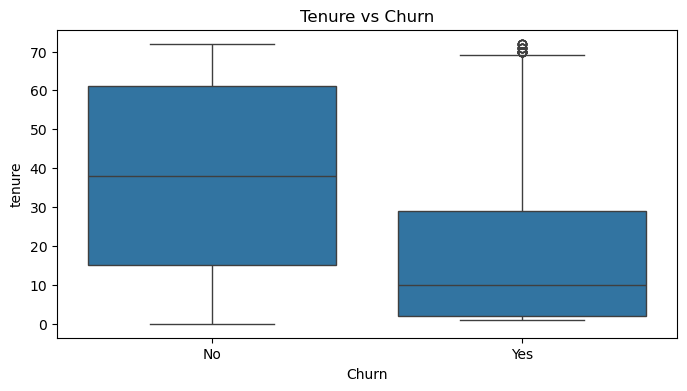

In [16]:
#tenure Vs Churn
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

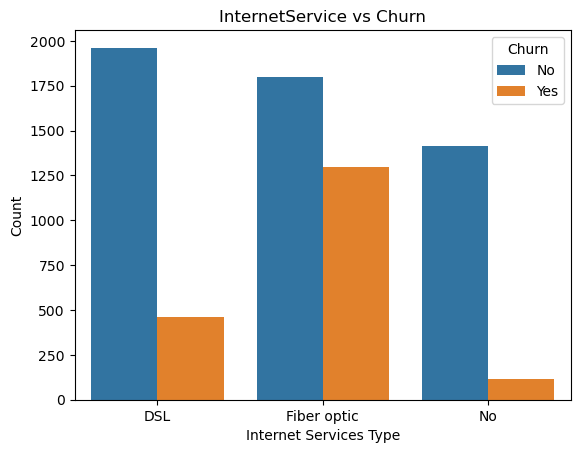

In [17]:
# InternetService vs Churn
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("InternetService vs Churn")
plt.xlabel("Internet Services Type")
plt.ylabel("Count")
plt.show()

Text(0, 0.5, 'Count')

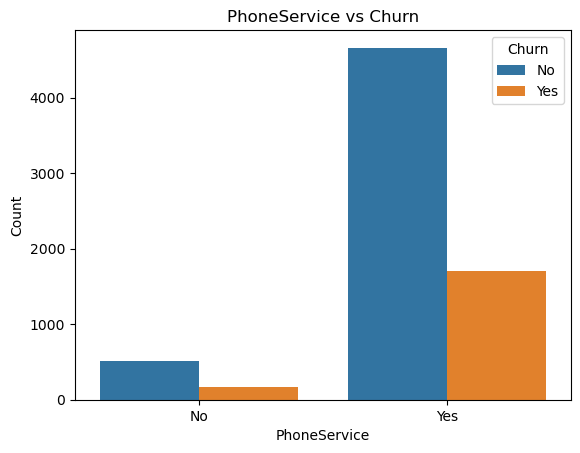

In [18]:
#PhoneService vs Churn
sns.countplot(x="PhoneService", hue="Churn", data=df)
plt.title("PhoneService vs Churn")
plt.xlabel("PhoneService")
plt.ylabel("Count")


In [19]:
#Data Preprocessing

In [20]:
#Label Encoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [32]:
#Feature Selection

In [21]:
##feature Selection
X=df[["tenure","PhoneService","InternetService","MonthlyCharges","TotalCharges"]].copy()
X["PhoneService"]=X["PhoneService"].map({"Yes":1,"No":0})
X["InternetService"]=le.fit_transform(X["InternetService"])
X["TotalCharges"]=pd.to_numeric(X["TotalCharges"],errors="coerce")

In [22]:
X.head(2)

,tenure,PhoneService,InternetService,MonthlyCharges,TotalCharges
0,1,0,0,29.85,29.85
1,34,1,0,56.95,1889.50


In [23]:
X.isnull().sum()

tenure              0
PhoneService        0
InternetService     0
MonthlyCharges      0
TotalCharges       11
dtype: int64

In [24]:
X["TotalCharges"]=X["TotalCharges"].fillna(X["TotalCharges"].median())

In [25]:
X.isnull().sum()

tenure             0
PhoneService       0
InternetService    0
MonthlyCharges     0
TotalCharges       0
dtype: int64

In [26]:
X.dtypes

tenure               int64
PhoneService         int64
InternetService      int32
MonthlyCharges     float64
TotalCharges       float64
dtype: object

In [66]:
#target Selection
Y=df["Churn"].map({"Yes":1,"No":0})
Y.head(2)

0    0
1    0
Name: Churn, dtype: int64

In [28]:
Y.isnull().sum()

0

In [29]:
print(X.shape)
print(Y.shape)

(7043, 5)
(7043,)


In [30]:
#Import train_test_Split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42)

In [31]:
#scale the feature
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [32]:
#train the model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

#fit the model
model.fit(X_train_scaled,Y_train)

LogisticRegression()

In [33]:
#predict the model
y_pred=model.predict(X_test_scaled)

In [37]:
#Evaluate the model
from sklearn.metrics import confusion_matrix,accuracy_score
print("Confusion Matrix:" , confusion_matrix(Y_test,y_pred))
print("Accuracy score:", accuracy_score(Y_test,y_pred))

Confusion Matrix: [[942  94]
 [188 185]]
Accuracy score: 0.7998580553584103


In [41]:
#Define a function for predict that the customer will churn or not
def Customer_data():
    cust_data={
        'tenure': int(input("Enter how many months you have a bond:")),
        'PhoneService':int(input("Enter 1 if you have phoneservice othervise 0 ")),
        'InternetService':int(input("Enter 1 for DSL,2 for Fibre optic or 0 for no")),
        'MonthlyCharges':float(input("Enter Monthly Charges")) ,
        'TotalCharges': float(input("Enter total charges")),
    }
   #conert dictionary into dataframe
    user_data=pd.DataFrame([cust_data])
    # now scale the data
    Scaled_cust_data=scaler.transform(user_data)

    # Predict on new data
    new_pred=model.predict(Scaled_cust_data)
    if new_pred[0]==0:
        print("Customer will not churn")
    else:
        print("Customer will churn")
     

In [42]:
Customer_data()

Enter how many months you have a bond: 72
Enter 1 if you have phoneservice othervise 0  1
Enter 1 for DSL,2 for Fibre optic or 0 for no 1
Enter Monthly Charges 20.67
Enter total charges 1500


Customer will not churn


In [46]:
Customer_data()

Enter how many months you have a bond: 56
Enter 1 if you have phoneservice othervise 0  1
Enter 1 for DSL,2 for Fibre optic or 0 for no 1
Enter Monthly Charges 789
Enter total charges 1500


Customer will churn
